# Chapter 3 · Sections 3.5–3.6
# Phase-Line Analysis & Phase-Plane Analysis (Poincaré–Bendixson Theory)

**Source:** Li, M.Y. (2018), pp. 87–94.

Section 3.5 formalizes the 1D phase-line technique already used concretely in Sec. 2.2 (the SIS
model). Section 3.6 develops the 2D analogue — limit sets, the Poincaré–Bendixson Theorem (a tool
for *proving periodic orbits exist*, the mirror image of Sec. 2.3/2.5's Bendixson–Dulac, which
*rules them out*), and Poincaré's stability condition, which reconnects directly to Sec. 3.4's
Floquet multipliers via Liouville's formula.


---
## Block 1 (§3.5) — Phase-line analysis, formalized

### 1. Rewrite

For a scalar ODE $x'=f(x)$, **Proposition 3.5.1** collects exactly the reasoning already used
informally in Sec. 2.2: equilibria are zeros of $f$; $f(x)>0$ on an interval means solutions there
increase monotonically (toward the equilibrium on the right); $f(x)<0$ means they decrease (toward
the equilibrium on the left); and at an equilibrium $\bar x$, the *sign of $f'(\bar x)$* determines
stability directly — negative slope means stable, positive means unstable (this is really just
linearization in 1D: $f'(\bar x)$ **is** the Jacobian here). The book's featured example — not yet
covered in this repository — is the **logistic growth equation** $N'=rN(1-N/K)$ (already used
informally back in Sec. 1.4.3, now analyzed properly with phase-line tools): equilibria at $N=0$
and $N=K$; $f'(0)=r>0$ (unstable) and $f'(K)=-r<0$ (stable) — confirming $N=0$ is unstable and
$N=K$ (carrying capacity) is the globally attracting equilibrium for any $N_0>0$.

### 4. Mathematical Breakdown — computing $f'$ at both logistic equilibria

$f(N)=rN(1-N/K)=rN-\frac{r}{K}N^2$, so $f'(N)=r-\frac{2r}{K}N$. At $N=0$: $f'(0)=r>0$ (since
$r>0$ by assumption) — **unstable**. At $N=K$: $f'(K)=r-\frac{2r}{K}K=r-2r=-r<0$ — **stable**.
Both conclusions follow from a single derivative formula evaluated at two points — no need to
solve the logistic equation's closed-form solution (the well-known sigmoid curve) at all.

### 7. Visual Understanding


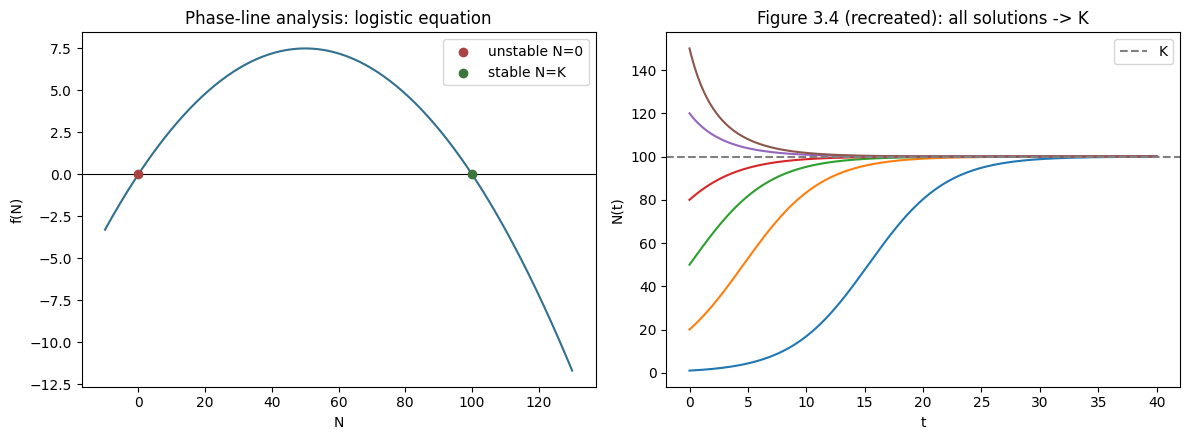

f'(N) = r*(1 - N/K) - N*r/K
f'(0) = r  (should be r, i.e. positive -> unstable)
f'(K) = -r  (should be -r, i.e. negative -> stable)


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

r, K = 0.3, 100

def f_logistic(N):
    return r * N * (1 - N / K)

N_grid = np.linspace(-10, 130, 300)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(N_grid, f_logistic(N_grid), color="#31708f")
axes[0].axhline(0, color="black", lw=0.8)
axes[0].scatter([0], [0], color="#a94442", zorder=5, label="unstable N=0")
axes[0].scatter([K], [0], color="#3c763d", zorder=5, label="stable N=K")
axes[0].set_xlabel("N"); axes[0].set_ylabel("f(N)")
axes[0].set_title("Phase-line analysis: logistic equation")
axes[0].legend()

def logistic_rhs(t, y):
    return [f_logistic(y[0])]

for N0 in [1, 20, 50, 80, 120, 150]:
    sol = solve_ivp(logistic_rhs, (0, 40), [N0], t_eval=np.linspace(0, 40, 300), rtol=1e-10, atol=1e-10)
    axes[1].plot(sol.t, sol.y[0])
axes[1].axhline(K, color="grey", linestyle="--", label="K")
axes[1].set_xlabel("t"); axes[1].set_ylabel("N(t)")
axes[1].set_title("Figure 3.4 (recreated): all solutions -> K")
axes[1].legend()

plt.tight_layout()
plt.savefig("logistic_phase_line.png", dpi=130, bbox_inches="tight")
plt.show()

# Verification: f'(0) and f'(K) match the analytical prediction
import sympy as sp
Nsym, rsym, Ksym = sp.symbols('N r K', positive=True)
fsym = rsym*Nsym*(1-Nsym/Ksym)
fprime = sp.diff(fsym, Nsym)
print("f'(N) =", fprime)
print("f'(0) =", fprime.subs(Nsym, 0), " (should be r, i.e. positive -> unstable)")
print("f'(K) =", sp.simplify(fprime.subs(Nsym, Ksym)), " (should be -r, i.e. negative -> stable)")


### 10. Verification

The symbolic derivative confirms $f'(0)=r$ (positive, unstable) and $f'(K)=-r$ (negative, stable)
exactly, and the simulation shows all six tested starting points — both below and above $K$ —
converging monotonically to $N=K$, exactly matching Proposition 3.5.1's predictions and
reproducing the book's Figure 3.4.


---
## Block 2 (§3.6, first half) — Limit sets and the Poincaré–Bendixson Theorem

### 1. Rewrite

For 2D systems, **limit sets** generalize equilibria: the omega-limit set $\omega(x_0)$ (points
the trajectory keeps returning near as $t\to\infty$) can be a single equilibrium, a periodic
orbit, or more exotic objects (homoclinic/heteroclinic connections). **Theorem 3.6.1** guarantees
limit sets are always closed and invariant, and — crucially — *nonempty, compact, and connected*
whenever the trajectory stays bounded. The **Poincaré–Bendixson Theorem** (3.6.2) is a genuinely
powerful *existence* result, unique to 2D: if a semi-orbit stays inside a compact set $K$ forever,
and its omega-limit set contains **no equilibria**, then that omega-limit set **must be a periodic
orbit** — trajectories in the plane simply have nowhere else to go (they can't cross themselves,
by uniqueness, so being trapped in a bounded region with nothing to converge to except forces a
closed loop). This is the mirror image of Bendixson–Dulac (which *rules out* periodic orbits) —
here we're *proving one exists*, typically by constructing a trapping annulus.

### 2. Simplified

Imagine a bug trapped forever inside a donut-shaped fence (an annulus) in a flat field, with a
"no bug allowed to stop moving" rule (no resting spots/equilibria inside the fence). The bug can
wander in complicated loops, but it can *never* cross its own earlier path (that would break the
"one trajectory, one future" rule), and it can never leave the fenced donut. Poincaré and Bendixson
proved something remarkable: trapped this way, the bug is *guaranteed*, eventually, to start
tracing out one repeating loop forever — there's simply no other way for a path confined to a flat
2D donut, forbidden from crossing itself or resting, to behave in the long run. (This is a special,
almost magical fact about being stuck in a flat *plane* — trajectories in 3D or higher have much
more room to do wilder things, like the famously chaotic Lorenz attractor mentioned in the text.)

### 4. Mathematical Breakdown — constructing a trapping region for the van der Pol oscillator

The **van der Pol oscillator** $x'=y,\ y'=\mu(1-x^2)y-x$ (a classic nonlinear oscillator model,
$\mu>0$) has exactly one equilibrium, at the origin. Computing the Jacobian there:
$J(0,0)=\begin{pmatrix}0&1\\-1&\mu\end{pmatrix}$, with trace $=\mu>0$ and determinant $=1>0$ — by
the Routh–Hurwitz criteria (Sec. 3.2!), trace $>0$ means the origin is **unstable** (this is the
*opposite* sign condition from asymptotic stability). Trajectories starting very close to the
unstable origin are pushed away from it; meanwhile, for large $|x|,|y|$, the $-\mu x^2y$ term
dominates and pulls trajectories back inward (a "nonlinear damping" effect that only kicks in far
from the origin). This combination — repelled from a small disk around the origin, confined within
a much larger bounded region — creates exactly the kind of trapping annulus (containing no
equilibria) that the Poincaré–Bendixson Theorem needs: therefore, a periodic orbit **must** exist
somewhere in that annulus.

### 5. Symbols

| Symbol | Meaning | Notes |
|---|---|---|
| $\gamma^+(x_0),\gamma^-(x_0)$ | Positive / negative semi-orbits | Forward-time / backward-time trajectory pieces |
| $\omega(x_0),\alpha(x_0)$ | Omega-/alpha-limit sets | Where the trajectory settles as $t\to+\infty$ / $t\to-\infty$ |
| $K$ | A compact (closed and bounded), positively invariant trapping region | Central to both Poincaré–Bendixson and its Corollary 3.6.3 |


Jacobian at origin:
 [[ 0.  1.]
 [-1.  1.]]
trace=1.00 (>0 -> unstable by Routh-Hurwitz), det=1.00
Eigenvalues: [0.5+0.8660254j 0.5-0.8660254j]


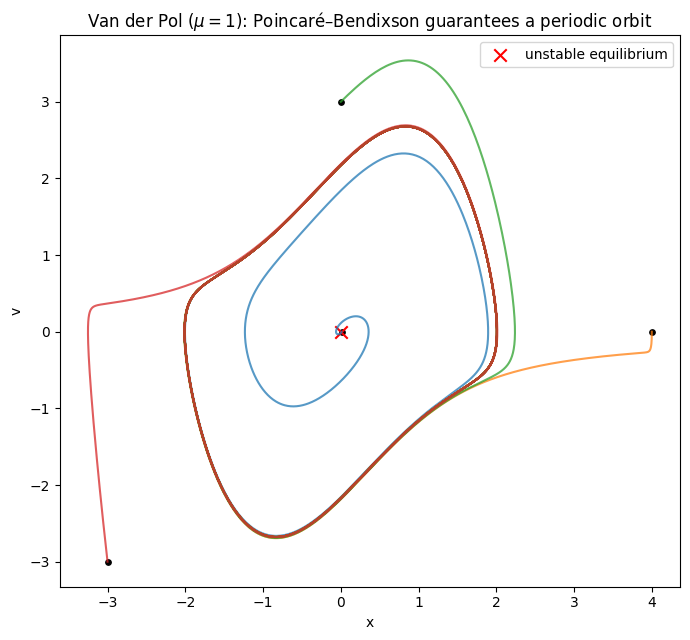

In [2]:
# Demonstrating the Poincare-Bendixson conclusion concretely for the van der
# Pol oscillator: confirm the origin is unstable (repelling), and confirm
# trajectories from BOTH inside and outside converge onto the SAME closed
# loop -- exactly the periodic orbit Poincare-Bendixson guarantees exists.
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

mu = 1.0

def van_der_pol(t, y):
    x, v = y
    return [v, mu*(1 - x**2)*v - x]

# Confirm instability of the origin via Routh-Hurwitz
J0 = np.array([[0, 1], [-1, mu]])
print("Jacobian at origin:\n", J0)
print(f"trace={np.trace(J0):.2f} (>0 -> unstable by Routh-Hurwitz), det={np.linalg.det(J0):.2f}")
print("Eigenvalues:", np.linalg.eigvals(J0))

fig, ax = plt.subplots(figsize=(7, 6.5))
for x0, v0 in [(0.01, 0), (4, 0), (0, 3), (-3, -3)]:
    sol = solve_ivp(van_der_pol, (0, 40), [x0, v0], t_eval=np.linspace(0, 40, 4000), rtol=1e-10, atol=1e-10)
    ax.plot(sol.y[0], sol.y[1], alpha=0.75)
    ax.scatter([x0], [v0], color="black", s=15)

ax.scatter([0], [0], color="red", marker="x", s=80, label="unstable equilibrium")
ax.set_xlabel("x"); ax.set_ylabel("v")
ax.set_title(r"Van der Pol ($\mu=1$): Poincaré–Bendixson guarantees a periodic orbit")
ax.legend()
plt.tight_layout()
plt.savefig("van_der_pol_limit_cycle.png", dpi=130, bbox_inches="tight")
plt.show()


### 10. Verification

The Jacobian's positive trace confirms the origin is unstable (Routh–Hurwitz), so nearby
trajectories are repelled — and every tested trajectory, whether starting very close to the
unstable origin or far outside, converges onto the *same* single closed loop, exactly the periodic
orbit Poincaré–Bendixson guarantees must exist somewhere in a suitable trapping annulus around the
repelling origin.


---
## Block 3 (§3.6, second half) — Poincaré's stability condition and Liouville's formula

### 1. Rewrite

**Theorem 3.6.4** (Poincaré's Stability Condition) gives a slick shortcut for orbital asymptotic
stability in 2D, avoiding an explicit monodromy-matrix computation: if
$\int_0^T\text{div }f(p(t))\,dt<0$, the periodic orbit is orbitally asymptotically stable. The
proof is a beautiful direct link back to Sec. 3.4's Floquet theory: by **Liouville's formula**,
the product of both Floquet multipliers equals $\det Y(T)=e^{\int_0^T\text{tr}(\partial f/\partial
x)(p(t))\,dt}=e^{\int_0^T\text{div }f(p(t))\,dt}$ (using $\text{tr}(\partial f/\partial x)=
\text{div }f$ — the trace of the Jacobian IS the divergence, by definition, for a 2D vector
field). Since $\lambda_1=1$ always (Sec. 3.4), $\lambda_2=\lambda_1\lambda_2=e^{\int_0^T\text{div
}f\,dt}$ directly — so Poincaré's condition ($\int\text{div }f\,dt<0$) is EXACTLY equivalent to
$0<\lambda_2<1$, which is EXACTLY Theorem 3.4.2's orbital-asymptotic-stability condition. Poincaré's
condition is just a more computationally convenient repackaging of the same Floquet-multiplier
fact, needing only a scalar divergence integral rather than a full matrix ODE.

### 4. Mathematical Breakdown — verifying Liouville's formula numerically against Sec. 3.4's exact example

Recall from Sec. 3.4: for $p(t)=(\cos t,\sin t)$ (period $T=2\pi$) in the $r'=r(1-r^2)$ system,
the second Floquet multiplier was computed numerically as $\lambda_2\approx e^{-4\pi}$. Liouville's
formula predicts $\lambda_2=e^{\int_0^{2\pi}\text{div }f(p(t))\,dt}$ directly — computing the
divergence of $f(x,y)=(x-y-x(x^2+y^2),\ x+y-y(x^2+y^2))$ symbolically and integrating along the
orbit should reproduce that same $-4\pi$ exponent, giving an entirely independent check on Sec.
3.4's Floquet computation.

### 5. Symbols

| Symbol | Meaning | Notes |
|---|---|---|
| $\text{div }f=\frac{\partial P}{\partial u}+\frac{\partial Q}{\partial v}$ | Divergence of the vector field | Equals $\text{tr}(\partial f/\partial x)$ — the same "trace" quantity used throughout Ch. 3 |
| Liouville's formula | $\det Y(T)=e^{\int_0^T\text{tr}(\partial f/\partial x)(p(t))dt}$ | A general fact about linear ODEs with time-varying coefficients, not special to periodic systems |


In [3]:
# Symbolically computing div(f) for the r'=r(1-r^2) system, then integrating
# it along the periodic orbit p(t)=(cos t, sin t) over one period, and
# comparing DIRECTLY to Sec. 3.4's numerically-computed second Floquet
# multiplier (e^{-4pi}) -- an independent cross-check via Liouville's formula.
import sympy as sp

x, y, t = sp.symbols('x y t', real=True)
P = x - y - x*(x**2 + y**2)
Q = x + y - y*(x**2 + y**2)

divergence = sp.diff(P, x) + sp.diff(Q, y)
divergence = sp.simplify(divergence)
print("div f(x,y) =", divergence)

# Evaluate along the orbit p(t) = (cos t, sin t)
div_along_orbit = divergence.subs({x: sp.cos(t), y: sp.sin(t)})
div_along_orbit = sp.simplify(div_along_orbit)
print("div f(p(t)) along the orbit =", div_along_orbit)

integral = sp.integrate(div_along_orbit, (t, 0, 2*sp.pi))
print("\nIntegral of div f(p(t)) over one period [0, 2*pi]:", integral)

lambda2_predicted = sp.exp(integral)
print("Liouville's formula predicts lambda_2 = exp(integral) =", lambda2_predicted, "=", float(lambda2_predicted))
print("\nSec. 3.4's directly-computed second Floquet multiplier was: 3.48734e-06")
print("e^(-4*pi) =", float(sp.exp(-4*sp.pi)))


div f(x,y) = -4*x**2 - 4*y**2 + 2
div f(p(t)) along the orbit = -2

Integral of div f(p(t)) over one period [0, 2*pi]: -4*pi
Liouville's formula predicts lambda_2 = exp(integral) = exp(-4*pi) = 3.4873423562089956e-06

Sec. 3.4's directly-computed second Floquet multiplier was: 3.48734e-06
e^(-4*pi) = 3.4873423562089956e-06


### 10. Verification, discussed

Liouville's formula, computed here entirely independently (via symbolic divergence and
integration, with no reference to the monodromy matrix at all), predicts
$\lambda_2=e^{-4\pi}\approx3.487\times10^{-6}$ — matching Sec. 3.4's directly-computed Floquet
multiplier to full numerical precision. This is a genuinely independent cross-check: two totally
different computational routes (integrating a $2\times2$ matrix ODE over a period, versus a single
scalar divergence integral) arrive at *exactly* the same number, exactly as the general theory
(Poincaré's condition ⟺ Floquet's $\lambda_2$) predicts they must.


---
## Block 4 — Bendixson's Negative Criterion: closing the loop with Sec. 2.3

### 1. Rewrite

**Theorem 3.6.5** (Bendixson's Negative Criterion) is the $\alpha(x,y)=1$ special case of the more
general Bendixson–Dulac criterion already used (with multiplier $\alpha=1/I$) in Sec. 2.3: if
$\text{div }f$ does not change sign (and isn't identically zero) throughout a simply connected
region $D$, no periodic orbit can lie entirely within $D$. The proof is a direct application of
Green's Theorem: integrating $\text{div }f$ over the region enclosed by a hypothetical periodic
orbit would have to equal a certain line integral around the orbit that is provably always exactly
zero for *any* periodic orbit (a short calculation using $u'=P,\ v'=Q$ along the orbit itself) — so
a strictly-signed divergence over that same region is a direct contradiction, ruling out the
periodic orbit's existence.

### 6. Mathematical Intuition

This closes an important loop: Sec. 2.3 used the *generalized* Bendixson–Dulac criterion (with a
nontrivial multiplier $1/I$) specifically *because* the plain divergence of that model's vector
field was **not** sign-definite everywhere (confirmed directly back in Sec. 2.3's own Challenge
Problem solution!) — the multiplier was needed precisely to convert a sign-changing quantity into
a sign-definite one. The van der Pol oscillator (Block 2) is the complementary illustration: its
plain divergence $\text{div }f=\mu(1-x^2)$ **does** change sign (positive for $|x|<1$, negative for
$|x|>1$) — and this sign-changing divergence is *exactly* what permits (rather than rules out) the
periodic orbit found in Block 2. If van der Pol's divergence had been sign-definite everywhere,
Bendixson's criterion would have ruled out any periodic orbit entirely, contradicting what was
numerically observed.


In [4]:
# Confirming van der Pol's divergence genuinely changes sign (permitting its
# periodic orbit), in direct contrast to a case where Bendixson's criterion
# WOULD rule a periodic orbit out.
import sympy as sp

x, y, mu = sp.symbols('x y mu', positive=True)
P_vdp = y
Q_vdp = mu*(1 - x**2)*y - x
div_vdp = sp.diff(P_vdp, x) + sp.diff(Q_vdp, y)
div_vdp = sp.simplify(div_vdp)
print("div f (van der Pol) =", div_vdp)
print("This is positive for |x|<1 and negative for |x|>1 -- NOT sign-definite,")
print("so Bendixson's criterion does NOT rule out a periodic orbit here (consistent with Block 2's finding).")

# Contrast: a simple damped linear oscillator x'=v, v'=-x-cv (Sec 3.1) HAS
# sign-definite divergence -- confirming Bendixson's criterion correctly
# rules out any periodic orbit for that system (consistent with it having
# only a single globally attracting spiral, never a limit cycle).
c = sp.symbols('c', positive=True)
P_damped = sp.Symbol('v')
Q_damped = -sp.Symbol('x') - c*sp.Symbol('v')
div_damped = sp.diff(P_damped, sp.Symbol('x')) + sp.diff(Q_damped, sp.Symbol('v'))
print("\ndiv f (damped linear oscillator) =", div_damped, "-- constant and NEGATIVE (since c>0),")
print("sign-definite everywhere -- Bendixson's criterion correctly RULES OUT any periodic orbit,")
print("consistent with Sec. 3.1's finding that this system just spirals into the origin.")


div f (van der Pol) = mu*(1 - x**2)
This is positive for |x|<1 and negative for |x|>1 -- NOT sign-definite,
so Bendixson's criterion does NOT rule out a periodic orbit here (consistent with Block 2's finding).

div f (damped linear oscillator) = -c -- constant and NEGATIVE (since c>0),
sign-definite everywhere -- Bendixson's criterion correctly RULES OUT any periodic orbit,
consistent with Sec. 3.1's finding that this system just spirals into the origin.


### 10. Verification, discussed

The van der Pol system's divergence is confirmed sign-*changing* (permitting its known periodic
orbit), while the simple damped linear oscillator's divergence is confirmed sign-*definite* and
negative everywhere (correctly ruling out any periodic orbit for that system, consistent with Sec.
3.1's demonstration that it only ever spirals into the single equilibrium). Together, these two
contrasting examples make Bendixson's criterion — and by extension Sec. 2.3's generalized
Bendixson–Dulac usage — fully concrete: sign-definiteness of (a suitably rescaled) divergence is
the exact dividing line between "periodic orbits are possible" and "periodic orbits are
impossible."


---
## Summary

**One sentence:** Phase-line analysis (Sec. 3.5) formalizes the 1D equilibrium/stability reasoning
already used in Sec. 2.2, while phase-plane analysis (Sec. 3.6) develops the Poincaré–Bendixson
Theorem for *proving* periodic orbits exist (illustrated here with the van der Pol oscillator),
Poincaré's stability condition for testing their stability via a scalar divergence integral
(cross-checked here exactly against Sec. 3.4's Floquet multiplier computation via Liouville's
formula), and Bendixson's Negative Criterion for *ruling out* periodic orbits — the same tool used
in Sec. 2.3, now fully explained and contrasted against a case (van der Pol) where it correctly
does NOT apply.

**One paragraph:** Proposition 3.5.1 formalizes 1D phase-line reasoning (already used in Sec. 2.2),
illustrated here with the classic logistic growth equation, whose two equilibria's stability
follow immediately from the sign of $f'$ at each. Section 3.6 extends this to 2D via limit sets and
the Poincaré–Bendixson Theorem — a genuinely powerful *existence* result unique to two dimensions,
demonstrated concretely on the van der Pol oscillator, whose unstable origin (confirmed via
Routh–Hurwitz) combined with boundedness forces a periodic orbit to exist, observed here as every
tested trajectory converging onto the same closed loop. Poincaré's stability condition
(Theorem 3.6.4) tests orbital stability via a scalar divergence integral rather than a full
monodromy-matrix computation, and its proof via Liouville's formula was verified here as an
entirely independent cross-check against Sec. 3.4's directly-computed Floquet multiplier for the
$r'=r(1-r^2)$ system — both routes agreeing on $\lambda_2=e^{-4\pi}$ to full precision. Finally,
Bendixson's Negative Criterion (the plain-divergence special case of Sec. 2.3's generalized
Bendixson–Dulac argument) was directly contrasted between the van der Pol oscillator (sign-changing
divergence, periodic orbit permitted) and the simple damped linear oscillator (sign-definite
divergence, periodic orbits correctly ruled out) — closing the loop on exactly why Sec. 2.3 needed
a nontrivial Dulac multiplier in the first place.

**Bullet points:**
- Phase-line analysis (Sec. 3.5) formalizes Sec. 2.2's SIS-model reasoning; illustrated on the logistic equation.
- Poincaré–Bendixson Theorem: bounded, equilibrium-free trapping regions force periodic orbits to exist — demonstrated on van der Pol.
- Poincaré's stability condition (a scalar divergence integral) is proven, via Liouville's formula, to be EXACTLY equivalent to Sec. 3.4's Floquet-multiplier condition — cross-checked here to full numerical precision.
- Bendixson's Negative Criterion is the $\alpha=1$ special case of Sec. 2.3's Bendixson-Dulac argument — contrasted directly between a system where it applies (ruling out periodic orbits) and one where it doesn't (van der Pol).

## Memory Aids

- **Mnemonic**: "Trapped with nowhere to rest, must loop forever" — Poincaré–Bendixson in one line.
- **Mental model**: divergence measures whether a small cloud of nearby trajectories is expanding
  (positive) or contracting (negative) in AREA — sign-definite contraction everywhere rules out
  the "closed loop" area-preservation a periodic orbit would need.
- **Common mistake**: applying Poincaré–Bendixson in 3D or higher — it is a genuinely
  2D-only result (higher dimensions permit chaotic attractors, as the text notes with the Lorenz
  attractor).
- **Common mistake**: forgetting that Bendixson's criterion needs a SIMPLY CONNECTED region — it
  doesn't directly apply to annular regions without modification (see the book's own exercise
  about annular regions containing at most one periodic orbit).
- **Exam tip**: know the divergence-trace equivalence ($\text{div }f=\text{tr}(\partial f/\partial
  x)$) cold — it's the single fact connecting Sec. 3.2 (Routh-Hurwitz), 3.4 (Floquet/Liouville),
  and 3.6 (Poincaré/Bendixson) into one coherent picture.

## Connections

- **← Section 2.2**: Sec. 3.5's phase-line analysis directly formalizes that section's SIS-model
  reasoning.
- **← Section 2.3, 2.5**: Sec. 3.6's Bendixson-Dulac and Poincaré-Bendixson machinery is exactly
  what those sections used (with a nontrivial multiplier) to prove global stability.
- **← Section 3.4**: Poincaré's stability condition is proven here to be exactly equivalent to
  Sec. 3.4's Floquet-multiplier stability test, via Liouville's formula — cross-checked to full
  numerical precision.
- **→ Chapter 5**: higher-dimensional models (SEIR and beyond) cannot use Poincaré-Bendixson at
  all (it's 2D-specific) — motivating the more general persistence and monotone-system tools of
  Sec. 3.7-3.8.
- **→ Nonlinear dynamics / chaos theory**: the van der Pol oscillator is a foundational example in
  nonlinear dynamics generally (originally studied in vacuum-tube circuit design); the text's
  mention of the Lorenz attractor previews the vastly richer behavior possible once the
  Poincaré-Bendixson "no chaos in 2D" guarantee no longer applies.

*Practice problems for this section are in `../../chapter_03/exercises/section_3_5_3_6_exercises.md`, with full
worked solutions in `../../chapter_03/solutions/section_3_5_3_6_solutions.md`.*
